In [59]:
import pandas as pd
import numpy as np
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

# -------------------------------
# Load dataset
# -------------------------------
df = pd.read_csv("data/output/Traffic_PowerBI_Ready_Monthly.csv")  # replace with your path

TARGET = "TOTAL"

# -------------------------------
# Numeric columns and imputation
# -------------------------------
numeric_cols = [
    "Autos", "Buses", "CASH", "CLASS 1", "CLASS 2", "CLASS 3", "CLASS 4",
    "CLASS 5", "CLASS 6", "CLASS 7", "CLASS 8", "CLASS 9", "CLASS 11",
    "EZPASS", "LANE", "Small_T", "Large_T", "VIOLATION"
]

# Impute median + add missing indicator
for col in numeric_cols:
    df[col + "_wasnull"] = df[col].isnull().astype(int)
    df[col] = df[col].fillna(df[col].median())

# -------------------------------
# Categorical encoding
# -------------------------------
categorical_cols = ["FAC_B"]
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# -------------------------------
# Time-series features (lags and rolling windows)
# -------------------------------
# Example for target lag/rolling windows
df["_target_lag1"] = df[TARGET].shift(1)
df["_target_min_w2"] = df[TARGET].rolling(window=2).min()
df["_target_max_w2"] = df[TARGET].rolling(window=2).max()
df["_target_mean_w2"] = df[TARGET].rolling(window=2).mean()

# Fill NaN created by rolling
df[["_target_lag1", "_target_min_w2", "_target_max_w2", "_target_mean_w2"]] = \
    df[["_target_lag1", "_target_min_w2", "_target_max_w2", "_target_mean_w2"]].fillna(0)

# -------------------------------
# Drop ignored columns
# -------------------------------
df = df.drop(columns=["FAC", "month_year"], errors='ignore')

# -------------------------------
# Features and target
# -------------------------------
X = df.drop(TARGET, axis=1)
y = df[TARGET].values

# -------------------------------
# Scale features
# -------------------------------
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, shuffle=False  # keep temporal order
)

# -------------------------------
# Train ExtraTreesRegressor
# -------------------------------
model = ExtraTreesRegressor(
    n_estimators=600,
    max_features=0.4,
    min_samples_split=0.09,
    min_samples_leaf=0.002,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

# -------------------------------
# Evaluate model
# -------------------------------
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")

# -------------------------------
# Feature importances
# -------------------------------
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importances)


RMSE: 181384.20734740424
R2 Score: 0.9021269528177579
              Feature  Importance
13             EZPASS    0.252263
15              Autos    0.205901
2             CLASS 1    0.192560
12               CASH    0.046251
3             CLASS 2    0.038563
0               FAC_B    0.033730
11           CLASS 11    0.030867
16            Small_T    0.028872
37       _target_lag1    0.018595
38     _target_min_w2    0.017842
1                LANE    0.014573
5             CLASS 4    0.014567
8             CLASS 7    0.014376
4             CLASS 3    0.013682
9             CLASS 8    0.012912
10            CLASS 9    0.012184
18              Buses    0.011532
6             CLASS 5    0.010008
14          VIOLATION    0.009061
17            Large_T    0.008984
39     _target_max_w2    0.006046
7             CLASS 6    0.004710
40    _target_mean_w2    0.001922
23    CLASS 2_wasnull    0.000000
24    CLASS 3_wasnull    0.000000
19      Autos_wasnull    0.000000
21       CASH_wasnull    0.0

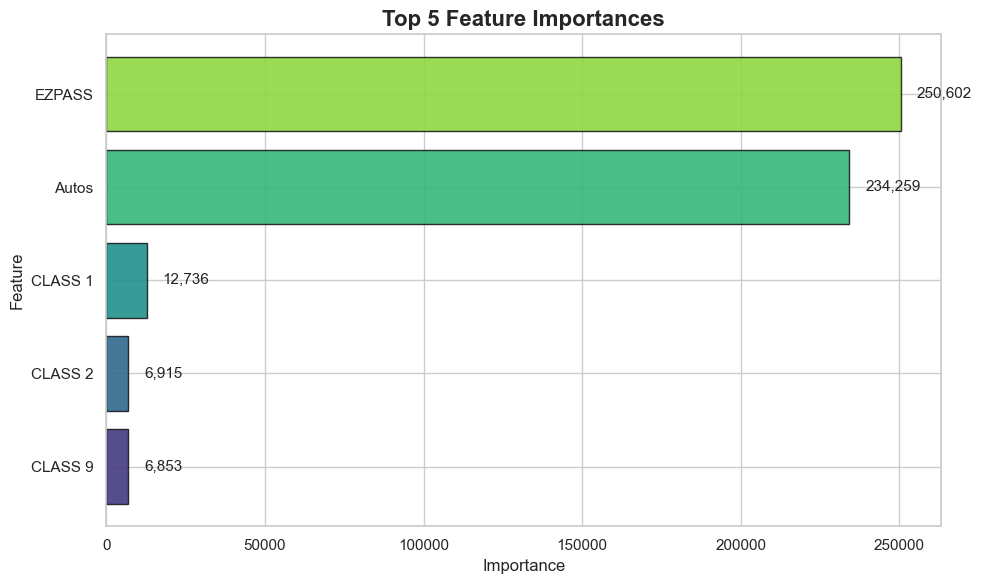

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -------------------------------
# Feature names and importance values
# -------------------------------
global_name = [
    "EZPASS", "Autos", "CLASS 1", "CLASS 2", "CLASS 9",
    "CASH", "Small_T", "CLASS 7", "VIOLATION", "CLASS 5"
]
global_value = [
    250602.05, 234258.82, 12735.51, 6914.96, 6853.38,
    4463.31, 3324.60, 2269.53, 1889.56, 1859.73
]

# Create DataFrame
df = pd.DataFrame({
    "Feature": global_name,
    "Importance": global_value
})

# Select top 5 features
top5 = df.sort_values(by="Importance", ascending=False).head(5)

# -------------------------------
# Plot horizontal bar chart
# -------------------------------
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Gradient color: use reversed 'viridis' colormap
colors = sns.color_palette("viridis", len(top5))[::-1]

bars = plt.barh(top5["Feature"], top5["Importance"], color=colors, edgecolor='k', alpha=0.9)

# Annotate values on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5000, bar.get_y() + bar.get_height()/2, f'{width:,.0f}', va='center', fontsize=11)

plt.title("Top 5 Feature Importances", fontsize=16, weight='bold')
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.gca().invert_yaxis()  # largest on top
plt.tight_layout()
plt.show()
